# **Creating Data Frames**

In [ ]:
import pandas as pd

In [ ]:
my_dict = {"title": "Charlotte's Web","author": "E.B. White","published": 1952}
my_dict["title"]

"Charlotte's Web"

In [ ]:
# From a list of dictionaries
# --> Constructed row by row
list_of_dicts = [{"name": "Ginger", "breed": "Dachshund", "height_cm": 22,"weight_kg": 10, "date_of_birth": "2019-03-14"},
 {"name": "Scout", "breed": "Dalmatian", "height_cm": 59, "weight_kg": 25, "date_of_birth": "2019-05-09"}]
my_df = pd.DataFrame(list_of_dicts)
print(my_df)

     name      breed  height_cm  weight_kg date_of_birth
0  Ginger  Dachshund         22         10    2019-03-14
1   Scout  Dalmatian         59         25    2019-05-09


In [ ]:
# From a dictionary of lists
# --> Constructed column by column
dict_of_lists = {"name": ["Ginger", "Scout"],"breed": ["Dachshund", "Dalmatian"],
                 "height_cm": [22, 59],"weight_kg": [10, 25],"date_of_birth": ["2019-03-14","2019-05-09"]}

new_dogs = pd.DataFrame(dict_of_lists)
print(new_dogs)

     name      breed  height_cm  weight_kg date_of_birth
0  Ginger  Dachshund         22         10    2019-03-14
1   Scout  Dalmatian         59         25    2019-05-09


# ** Reading and Writing CSVs files**

In [ ]:
"""What's a CSV file?"""
# CSV = comma-separated values
# Designed for DataFrame-like data
# Most database and spreadsheet programs can use them or create them
dataFrame = pd.read_csv("/content/sample_data/project1_df.csv")
dataFrame.head(2)

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location
0,943146,5876328741,Female,25-45,30/08/2023 20:27:08,Electronics,Yes,FESTIVE50,64.30,725.304000,661.004000,Credit Card,Ahmedabad
1,180079,1018503182,Male,25-45,23/02/2024 09:33:46,Electronics,Yes,SEASONALOFFER21,175.19,4638.991875,4463.801875,Credit Card,Bangalore


In [ ]:
# DataFrame to CSV
new_dogs.to_csv("new_dogs_with_bmi.csv")



---



# **Visualizing Data**

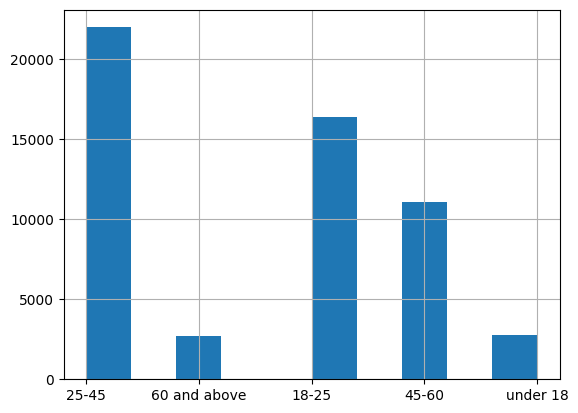

In [ ]:
import matplotlib.pyplot as plt
dataFrame['Age Group'].hist()
plt.show()

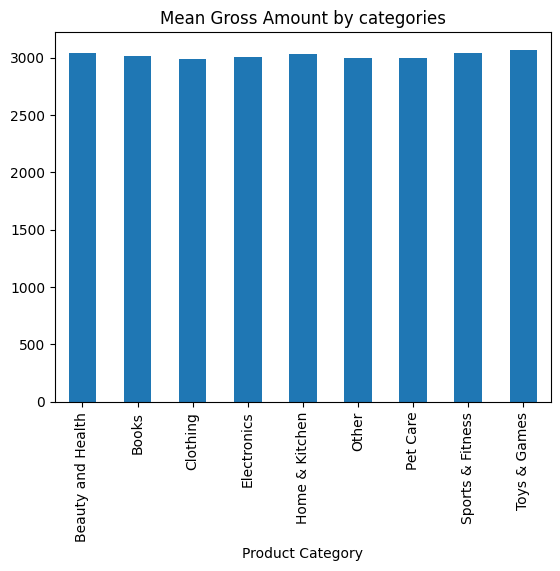

In [ ]:
# categories with each mean gross amount
categories_gross_mean = dataFrame.groupby("Product Category")["Gross Amount"].mean()
categories_gross_mean.plot(kind = "bar", title= "Mean Gross Amount by categories")
plt.show()

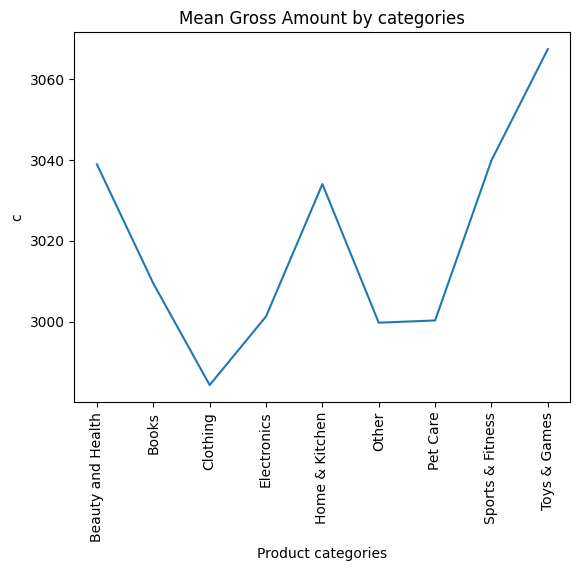

In [ ]:
categories_gross_mean.plot(kind = "line",ylabel="c",xlabel = "Product categories", title= "Mean Gross Amount by categories" , rot = 90)
plt.show()

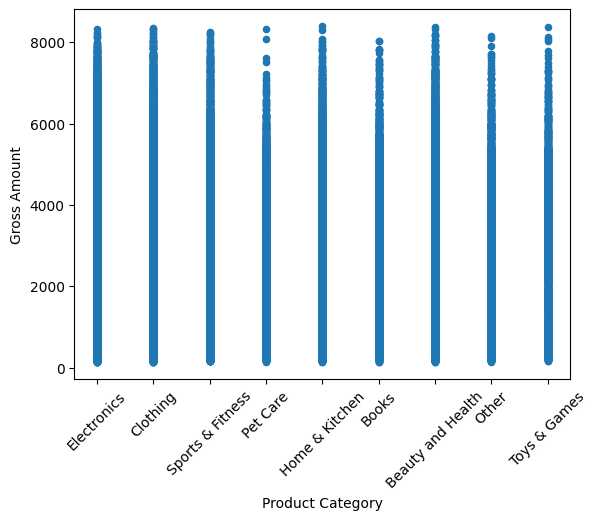

In [ ]:
dataFrame.plot(x ="Product Category" ,y = "Gross Amount", rot = 45 , kind = "scatter")
plt.show()

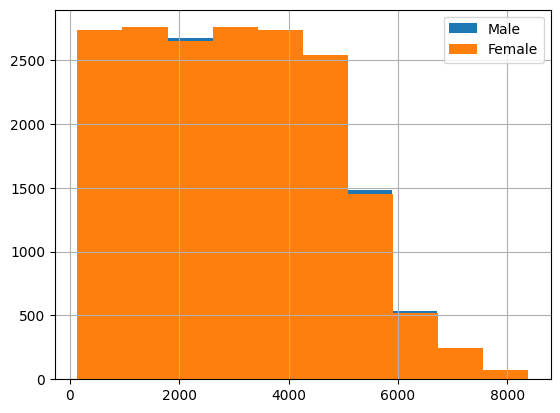

In [ ]:
dataFrame[dataFrame["Gender"] == "Male"]["Gross Amount"].hist()
dataFrame[dataFrame["Gender"] == "Female"]["Gross Amount"].hist()
plt.legend(["Male","Female"])
plt.show()

# **Missing Values**

In [ ]:
dataFrame.isna().any()

,0
CID,False
TID,False
Gender,False
Age Group,False
Purchase Date,False
Product Category,False
Discount Availed,False
Discount Name,True
Discount Amount (INR),False
Gross Amount,False


In [ ]:
dataFrame.isna().sum()

,0
CID,0
TID,0
Gender,0
Age Group,0
Purchase Date,0
Product Category,0
Discount Availed,0
Discount Name,27585
Discount Amount (INR),0
Gross Amount,0


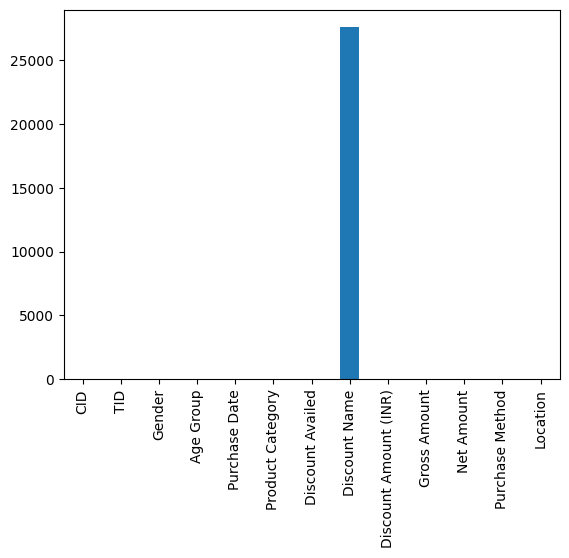

In [ ]:
dataFrame.isna().sum().plot(kind = "bar")
plt.show()

In [ ]:
# Replacing
dataFrame.fillna(0)

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location
0,943146,5876328741,Female,25-45,30/08/2023 20:27:08,Electronics,Yes,FESTIVE50,64.30,725.304000,661.004000,Credit Card,Ahmedabad
1,180079,1018503182,Male,25-45,23/02/2024 09:33:46,Electronics,Yes,SEASONALOFFER21,175.19,4638.991875,4463.801875,Credit Card,Bangalore
2,337580,3814082218,Other,60 and above,06/03/2022 09:09:50,Clothing,Yes,SEASONALOFFER21,211.54,1986.372575,1774.832575,Credit Card,Delhi
3,180333,1395204173,Other,60 and above,04/11/2020 04:41:57,Sports & Fitness,No,0,0.00,5695.612650,5695.612650,Debit Card,Delhi
4,447553,8009390577,Male,18-25,31/05/2022 17:00:32,Sports & Fitness,Yes,WELCOME5,439.92,2292.651500,1852.731500,Credit Card,Delhi
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54995,295864,5407639888,Other,25-45,23/02/2020 10:42:04,Electronics,Yes,SEASONALOFFER21,110.89,2819.907300,2709.017300,Debit Card,Other
54996,706435,1144029904,Other,18-25,12/07/2021 15:59:21,Electronics,Yes,SEASONALOFFER21,488.59,3891.303900,3402.713900,Cash on Delivery,Bangalore
54997,649435,9587323189,Male,45-60,02/08/2024 09:30:44,Home & Kitchen,Yes,NEWYEARS,417.63,4094.687500,3677.057500,Credit Card,Mumbai
54998,982183,5032564481,Female,45-60,05/08/2020 23:57:56,Beauty and Health,Yes,SEASONALOFFER21,204.56,3977.473500,3772.913500,Credit Card,Kolkata


In [ ]:
# Removing
dataFrame.dropna()